# Google Play Store Analysis

## Objective

Perform data analysis on the Google Play Store ecosystem by cleaning app data, exploring categories, ratings, size, installs, pricing, and performing sentiment analysis on user reviews.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Load the Datasets

The Google Play Store Apps dataset and User Reviews dataset are loaded separately for analysis.

In [2]:
apps_df = pd.read_csv("googleplaystore.csv")

apps_df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [3]:
reviews_df = pd.read_csv("googleplaystore_user_reviews.csv")

reviews_df.head()

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


## 2. Data Cleaning

The datasets are checked for missing values before performing further cleaning.

In [4]:
print("Missing values in Apps Dataset:")
print(apps_df.isnull().sum())

print("\nMissing values in User Reviews Dataset:")
print(reviews_df.isnull().sum())

Missing values in Apps Dataset:
App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

Missing values in User Reviews Dataset:
App                           0
Translated_Review         26868
Sentiment                 26863
Sentiment_Polarity        26863
Sentiment_Subjectivity    26863
dtype: int64


### Handling Missing Values

Missing values are handled to ensure that the datasets are suitable for further analysis.

In [5]:
# Handle missing values in Apps dataset

apps_df['Rating'] = apps_df['Rating'].fillna(apps_df['Rating'].median())
apps_df['Type'] = apps_df['Type'].fillna(apps_df['Type'].mode()[0])

# Remove reviews with missing review text
reviews_df = reviews_df.dropna(subset=['Translated_Review'])


### Fixing Incorrect Data Types

The `Installs` and `Price` columns contain symbols and characters that prevent numerical analysis. These values are cleaned and converted into numeric data types.

In [6]:
# Remove malformed rows from the Apps dataset

invalid_category = pd.to_numeric(apps_df['Category'], errors='coerce').notna()

apps_df = apps_df[~invalid_category].copy()

# Convert Installs to numeric
apps_df['Installs'] = (
    apps_df['Installs']
    .astype(str)
    .str.replace(',', '', regex=False)
    .str.replace('+', '', regex=False)
    .astype(float)
)

# Convert Price to numeric
apps_df['Price'] = (
    apps_df['Price']
    .astype(str)
    .str.replace('$', '', regex=False)
    .astype(float)
)

print("Data types after conversion:")
print(apps_df[['Installs', 'Price']].dtypes)

Data types after conversion:
Installs    float64
Price       float64
dtype: object


### Removing Duplicate Records

Duplicate records are removed from both datasets to avoid repeated information and ensure accurate analysis.

In [7]:
# Check duplicate records

print("Duplicate rows in Apps Dataset:", apps_df.duplicated().sum())
print("Duplicate rows in User Reviews Dataset:", reviews_df.duplicated().sum())

# Remove duplicate records

apps_df = apps_df.drop_duplicates()
reviews_df = reviews_df.drop_duplicates()

print("\nDuplicates removed successfully.")
print("Apps Dataset shape:", apps_df.shape)
print("User Reviews Dataset shape:", reviews_df.shape)

Duplicate rows in Apps Dataset: 483
Duplicate rows in User Reviews Dataset: 7735

Duplicates removed successfully.
Apps Dataset shape: (10357, 13)
User Reviews Dataset shape: (29692, 5)


### Final Data Cleaning Check

The cleaned datasets are checked to confirm that the required columns have the correct data types and that the datasets are ready for analysis.

In [8]:
print("Apps Dataset:")
print(apps_df[['Category', 'Rating', 'Installs', 'Type', 'Price']].dtypes)

print("\nUser Reviews Dataset:")
print(reviews_df[['App', 'Translated_Review']].dtypes)

print("\nApps Dataset Shape:", apps_df.shape)
print("User Reviews Dataset Shape:", reviews_df.shape)

Apps Dataset:
Category        str
Rating      float64
Installs    float64
Type            str
Price       float64
dtype: object

User Reviews Dataset:
App                  str
Translated_Review    str
dtype: object

Apps Dataset Shape: (10357, 13)
User Reviews Dataset Shape: (29692, 5)


## 3. Category Analysis

The distribution of apps across different categories is analysed to identify the most saturated categories in the Google Play Store.

In [9]:
# Count apps in each category

category_counts = apps_df['Category'].value_counts()

print(category_counts)

Category
FAMILY                 1943
GAME                   1121
TOOLS                   843
BUSINESS                427
MEDICAL                 408
PRODUCTIVITY            407
PERSONALIZATION         388
LIFESTYLE               373
COMMUNICATION           366
FINANCE                 360
SPORTS                  351
PHOTOGRAPHY             322
HEALTH_AND_FITNESS      306
SOCIAL                  280
NEWS_AND_MAGAZINES      264
TRAVEL_AND_LOCAL        237
BOOKS_AND_REFERENCE     230
SHOPPING                224
DATING                  196
VIDEO_PLAYERS           175
MAPS_AND_NAVIGATION     137
EDUCATION               130
FOOD_AND_DRINK          124
ENTERTAINMENT           111
AUTO_AND_VEHICLES        85
LIBRARIES_AND_DEMO       85
WEATHER                  82
HOUSE_AND_HOME           80
ART_AND_DESIGN           65
EVENTS                   64
COMICS                   60
PARENTING                60
BEAUTY                   53
Name: count, dtype: int64


## 4. Ratings Analysis

The distribution of app ratings is analysed to understand how apps are rated by users on the Google Play Store.

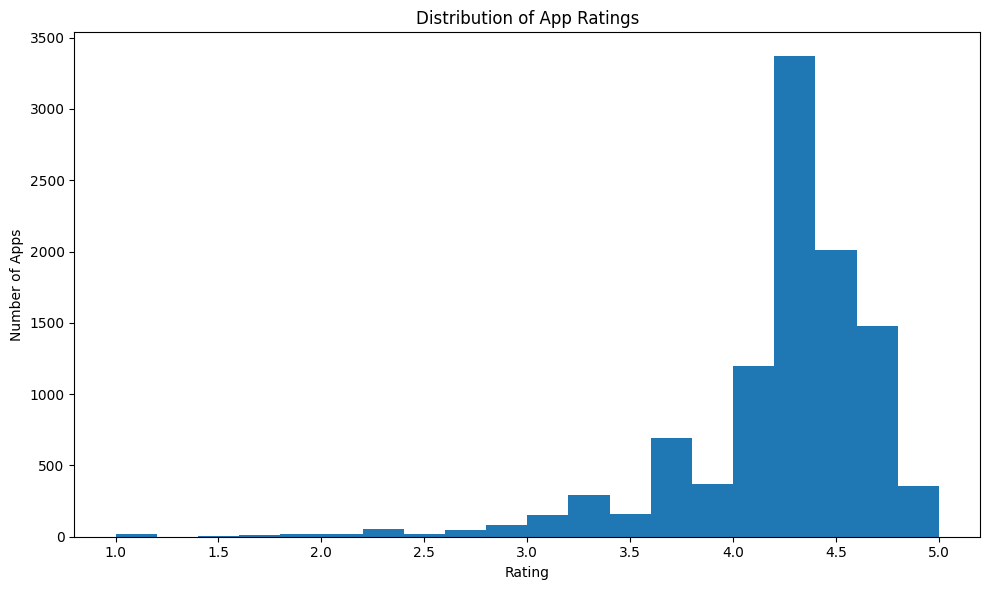

In [10]:
# Distribution of app ratings

plt.figure(figsize=(10, 6))

plt.hist(apps_df['Rating'].dropna(), bins=20)

plt.title('Distribution of App Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Apps')

plt.tight_layout()
plt.show()

### Average Rating by Category

The average rating of apps is calculated for each category to compare user ratings across different app categories.

In [11]:
# Calculate average rating by category

average_rating_category = apps_df.groupby('Category')['Rating'].mean().sort_values(ascending=False)

print(average_rating_category)

Category
EVENTS                 4.395313
EDUCATION              4.375385
ART_AND_DESIGN         4.355385
BOOKS_AND_REFERENCE    4.336522
PERSONALIZATION        4.327062
PARENTING              4.300000
BEAUTY                 4.283019
GAME                   4.282070
HEALTH_AND_FITNESS     4.266993
SOCIAL                 4.260714
SHOPPING               4.256250
WEATHER                4.248780
SPORTS                 4.239031
PRODUCTIVITY           4.219410
MEDICAL                4.212990
LIBRARIES_AND_DEMO     4.207059
AUTO_AND_VEHICLES      4.205882
FAMILY                 4.203757
PHOTOGRAPHY            4.189441
HOUSE_AND_HOME         4.185000
FOOD_AND_DRINK         4.183871
COMMUNICATION          4.175410
BUSINESS               4.175176
NEWS_AND_MAGAZINES     4.160985
COMICS                 4.160000
FINANCE                4.148056
ENTERTAINMENT          4.136036
LIFESTYLE              4.133244
TRAVEL_AND_LOCAL       4.121941
VIDEO_PLAYERS          4.084000
TOOLS                  4.080071

### Average Rating by Category

The average rating for each app category is visualised to compare user ratings across categories.

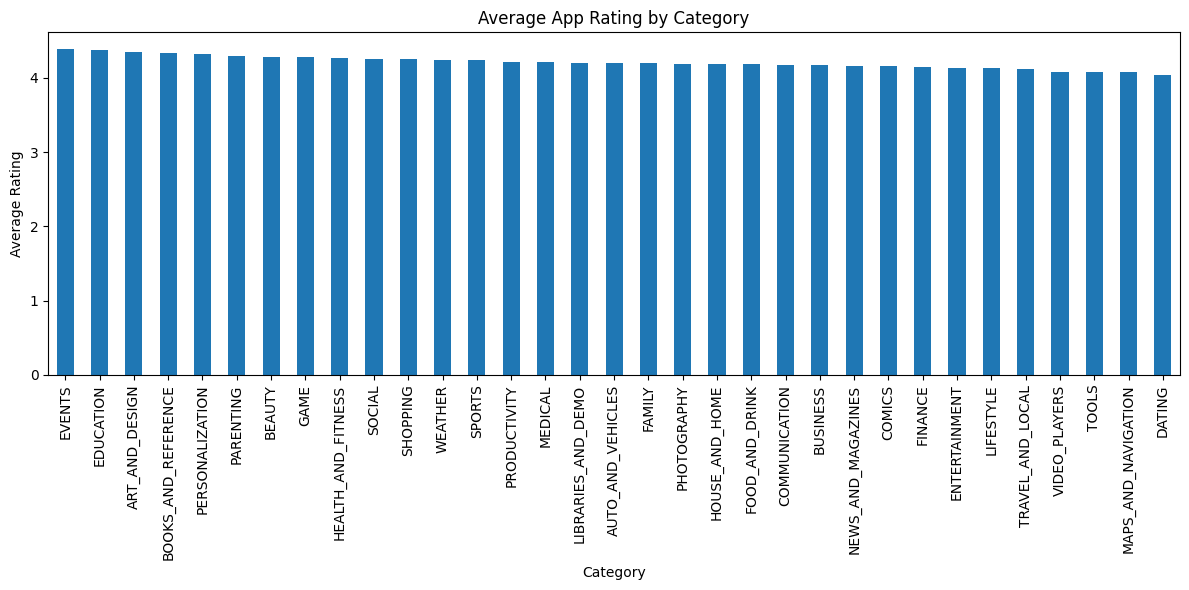

In [12]:
# Bar chart of average rating by category

plt.figure(figsize=(12, 6))

average_rating_category.plot(kind='bar')

plt.title('Average App Rating by Category')
plt.xlabel('Category')
plt.ylabel('Average Rating')
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

## 5. Size and Installs Analysis

The relationship between app size and the number of installs is analysed using a scatter plot to determine whether app size is associated with app popularity.

In [13]:
# Convert app Size into numeric values

def convert_size(size):
    if 'M' in str(size):
        return float(str(size).replace('M', ''))
    elif 'k' in str(size):
        return float(str(size).replace('k', '')) / 1024
    else:
        return np.nan

apps_df['Size_MB'] = apps_df['Size'].apply(convert_size)

print(apps_df[['Size', 'Size_MB', 'Installs']].head())

   Size  Size_MB    Installs
0   19M     19.0     10000.0
1   14M     14.0    500000.0
2  8.7M      8.7   5000000.0
3   25M     25.0  50000000.0
4  2.8M      2.8    100000.0


### App Size vs. Number of Installs

A scatter plot is used to examine the relationship between app size and the number of installs.

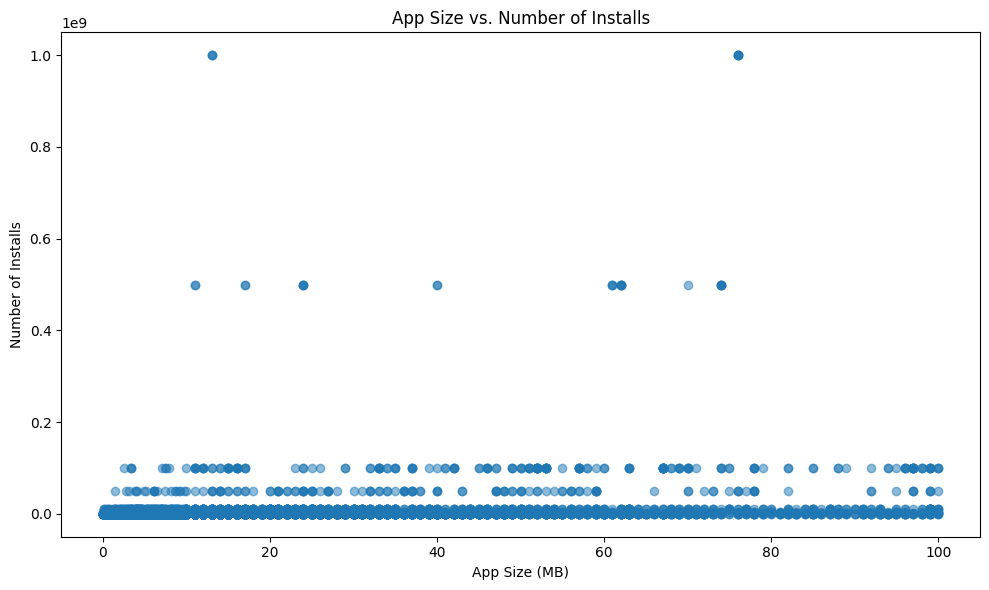

In [14]:
# Remove rows with missing Size or Installs values

size_installs = apps_df.dropna(subset=['Size_MB', 'Installs'])

# Scatter plot

plt.figure(figsize=(10, 6))

plt.scatter(size_installs['Size_MB'], size_installs['Installs'], alpha=0.5)

plt.title('App Size vs. Number of Installs')
plt.xlabel('App Size (MB)')
plt.ylabel('Number of Installs')

plt.tight_layout()
plt.show()

### Observation

The scatter plot shows the relationship between app size and the number of installs. The distribution of points can be used to determine whether larger apps tend to have more or fewer installs.

In [15]:
# Calculate correlation between app size and installs

correlation = size_installs['Size_MB'].corr(size_installs['Installs'])

print("Correlation between App Size and Installs:", correlation)

Correlation between App Size and Installs: 0.16887201973119784


### Observation

The correlation between app size and number of installs is approximately 0.169, indicating a weak positive relationship. This means that larger apps tend to have slightly more installs, but app size alone is not a strong predictor of app popularity.

## 6. Pricing Analysis

This section analyses the distribution of free and paid apps, the price distribution of paid apps, and the estimated revenue by app category.

In [16]:
type_counts = apps_df['Type'].value_counts()

print("Free vs Paid Apps:")
print(type_counts)

Free vs Paid Apps:
Type
Free    9592
Paid     765
Name: count, dtype: int64


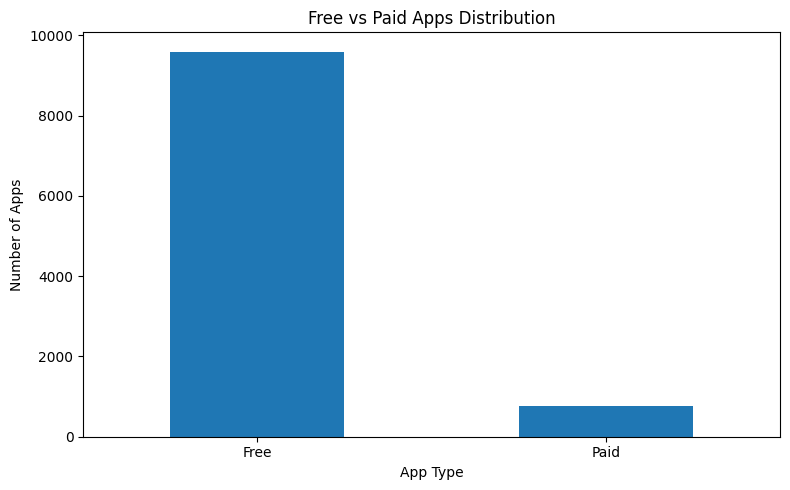

In [17]:
plt.figure(figsize=(8, 5))
type_counts.plot(kind='bar')
plt.title('Free vs Paid Apps Distribution')
plt.xlabel('App Type')
plt.ylabel('Number of Apps')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Observation

The dataset contains significantly more free apps than paid apps. This indicates that the Google Play Store is dominated by free applications, while paid applications represent a smaller portion of the market.

##  Price Distribution for Paid Apps

This section analyses the prices of paid applications to understand the pricing range and how the prices are distributed across paid apps.

In [18]:
paid_apps = apps_df[apps_df['Type'] == 'Paid']

print("Number of Paid Apps:", len(paid_apps))
print("\nPrice Statistics:")
print(paid_apps['Price'].describe())

Number of Paid Apps: 765

Price Statistics:
count    765.000000
mean      13.955556
std       58.406966
min        0.990000
25%        1.490000
50%        2.990000
75%        4.990000
max      400.000000
Name: Price, dtype: float64


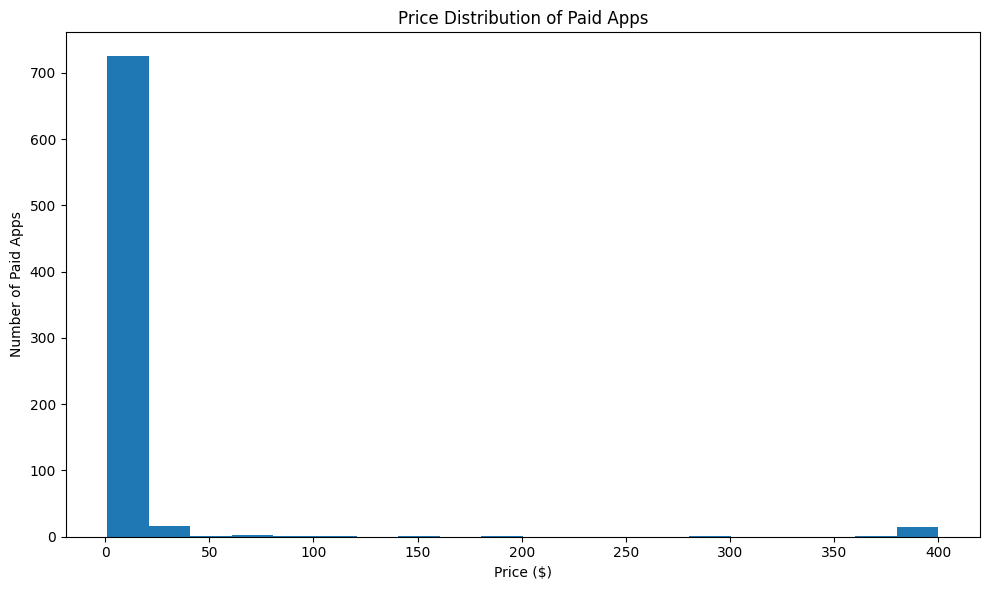

In [19]:
plt.figure(figsize=(10, 6))
plt.hist(paid_apps['Price'], bins=20)
plt.title('Price Distribution of Paid Apps')
plt.xlabel('Price ($)')
plt.ylabel('Number of Paid Apps')
plt.tight_layout()
plt.show()

### Observation

The price distribution shows that most paid apps are available at relatively low prices, while only a small number of apps have higher prices. This indicates that developers generally keep paid app prices affordable.

## Estimated Revenue by Category

Estimated revenue is calculated for paid apps by multiplying the app price by the number of installs. The estimated revenue is then aggregated by app category.

In [20]:
paid_apps = apps_df[apps_df['Type'] == 'Paid'].copy()

paid_apps['Estimated_Revenue'] = paid_apps['Price'] * paid_apps['Installs']

revenue_by_category = (
    paid_apps.groupby('Category')['Estimated_Revenue']
    .sum()
    .sort_values(ascending=False)
)

print("Estimated Revenue by Category:")
print(revenue_by_category)

Estimated Revenue by Category:
Category
FAMILY                 1.857803e+08
LIFESTYLE              5.758394e+07
GAME                   4.098764e+07
FINANCE                2.572668e+07
PHOTOGRAPHY            8.942768e+06
MEDICAL                8.456536e+06
PERSONALIZATION        7.786948e+06
TOOLS                  5.464821e+06
SPORTS                 4.706212e+06
PRODUCTIVITY           4.313375e+06
COMMUNICATION          4.247364e+06
WEATHER                4.181380e+06
EDUCATION              2.403980e+06
HEALTH_AND_FITNESS     1.426069e+06
MAPS_AND_NAVIGATION    1.240789e+06
TRAVEL_AND_LOCAL       1.151504e+06
BUSINESS               1.050543e+06
ENTERTAINMENT          7.980000e+05
VIDEO_PLAYERS          3.352900e+05
FOOD_AND_DRINK         2.844000e+05
PARENTING              2.499590e+05
AUTO_AND_VEHICLES      1.001485e+05
BOOKS_AND_REFERENCE    9.022674e+04
DATING                 8.836150e+04
ART_AND_DESIGN         3.184000e+04
SHOPPING               3.014900e+04
NEWS_AND_MAGAZINES     6

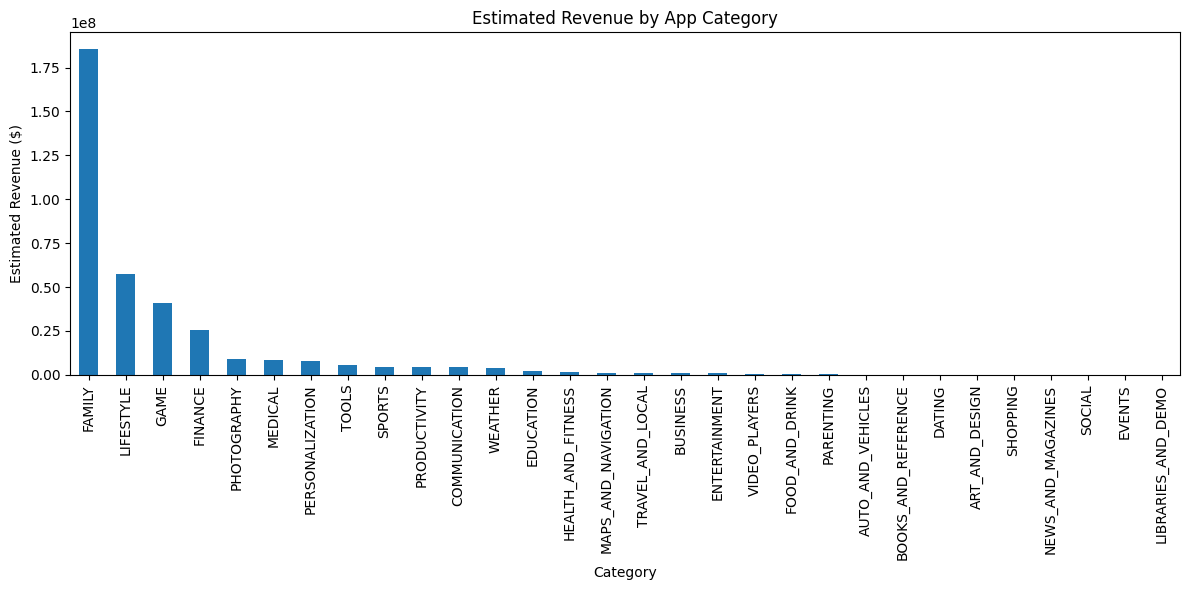

In [21]:
plt.figure(figsize=(12, 6))
revenue_by_category.plot(kind='bar')
plt.title('Estimated Revenue by App Category')
plt.xlabel('Category')
plt.ylabel('Estimated Revenue ($)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### Observation

The estimated revenue varies across app categories. Categories with higher estimated revenue may have a combination of higher-priced apps and larger numbers of installs. The revenue values are estimates because the dataset provides install ranges rather than exact install counts.

## 7. Sentiment Analysis

VADER sentiment analysis is used to classify user reviews into Positive, Negative, and Neutral sentiments based on the text of the review.

In [22]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

def classify_sentiment(text):
    score = analyzer.polarity_scores(str(text))['compound']
    
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

reviews_df['Predicted_Sentiment'] = reviews_df['Translated_Review'].apply(classify_sentiment)

print(reviews_df[['Translated_Review', 'Predicted_Sentiment']].head())

                                   Translated_Review Predicted_Sentiment
0  I like eat delicious food. That's I'm cooking ...            Positive
1    This help eating healthy exercise regular basis            Positive
3         Works great especially going grocery store            Positive
4                                       Best idea us            Positive
5                                           Best way            Positive


In [23]:
sentiment_counts = reviews_df['Predicted_Sentiment'].value_counts()

print("Sentiment Distribution:")
print(sentiment_counts)

Sentiment Distribution:
Predicted_Sentiment
Positive    20197
Negative     5866
Neutral      3629
Name: count, dtype: int64


### Observation

VADER successfully classified the user reviews into Positive, Negative, and Neutral sentiments. The sentiment distribution shows the overall opinion of users toward the apps in the dataset.

## Sentiment by Category

The sentiment of user reviews is analysed across different app categories to identify categories with the most positive and negative user sentiment.

In [24]:
##Connect reviews with app categories

apps_category = apps_df[['App', 'Category']].drop_duplicates('App')

reviews_with_category = reviews_df.merge(
    apps_category,
    on='App',
    how='left'
)

reviews_with_category = reviews_with_category.dropna(subset=['Category'])

print(reviews_with_category[['App', 'Category', 'Predicted_Sentiment']].head())

                     App            Category Predicted_Sentiment
0  10 Best Foods for You  HEALTH_AND_FITNESS            Positive
1  10 Best Foods for You  HEALTH_AND_FITNESS            Positive
2  10 Best Foods for You  HEALTH_AND_FITNESS            Positive
3  10 Best Foods for You  HEALTH_AND_FITNESS            Positive
4  10 Best Foods for You  HEALTH_AND_FITNESS            Positive


In [25]:
##8.3 Count sentiment by category

sentiment_by_category = pd.crosstab(
    reviews_with_category['Category'],
    reviews_with_category['Predicted_Sentiment']
)

print("Sentiment by Category:")
print(sentiment_by_category)

Sentiment by Category:
Predicted_Sentiment  Negative  Neutral  Positive
Category                                        
ART_AND_DESIGN             47       42       265
AUTO_AND_VEHICLES          14       36       233
BEAUTY                     64       62       191
BOOKS_AND_REFERENCE        99       71       447
BUSINESS                  111      130       416
COMICS                      1        5        39
COMMUNICATION             215      110       530
DATING                    242      160       685
EDUCATION                  67       70       507
ENTERTAINMENT             222      119       486
EVENTS                     19       12       125
FAMILY                    306      183      1313
FINANCE                   323      133       880
FOOD_AND_DRINK             89       64       430
GAME                      913      260      3171
HEALTH_AND_FITNESS        221      128      1272
HOUSE_AND_HOME             85       89       271
LIBRARIES_AND_DEMO         63       37       2

In [26]:
##Find most positive and negative categories
positive_by_category = (
    sentiment_by_category['Positive']
    .sort_values(ascending=False)
    .head(10)
)

negative_by_category = (
    sentiment_by_category['Negative']
    .sort_values(ascending=False)
    .head(10)
)

print("Top 10 Categories with Positive Sentiment:")
print(positive_by_category)

print("\nTop 10 Categories with Negative Sentiment:")
print(negative_by_category)

Top 10 Categories with Positive Sentiment:
Category
GAME                  3171
FAMILY                1313
HEALTH_AND_FITNESS    1272
TOOLS                  893
FINANCE                880
TRAVEL_AND_LOCAL       857
SPORTS                 811
MEDICAL                795
PRODUCTIVITY           786
DATING                 685
Name: Positive, dtype: int64

Top 10 Categories with Negative Sentiment:
Category
GAME                  913
FINANCE               323
FAMILY                306
TRAVEL_AND_LOCAL      290
TOOLS                 273
SPORTS                268
DATING                242
PRODUCTIVITY          222
ENTERTAINMENT         222
HEALTH_AND_FITNESS    221
Name: Negative, dtype: int64


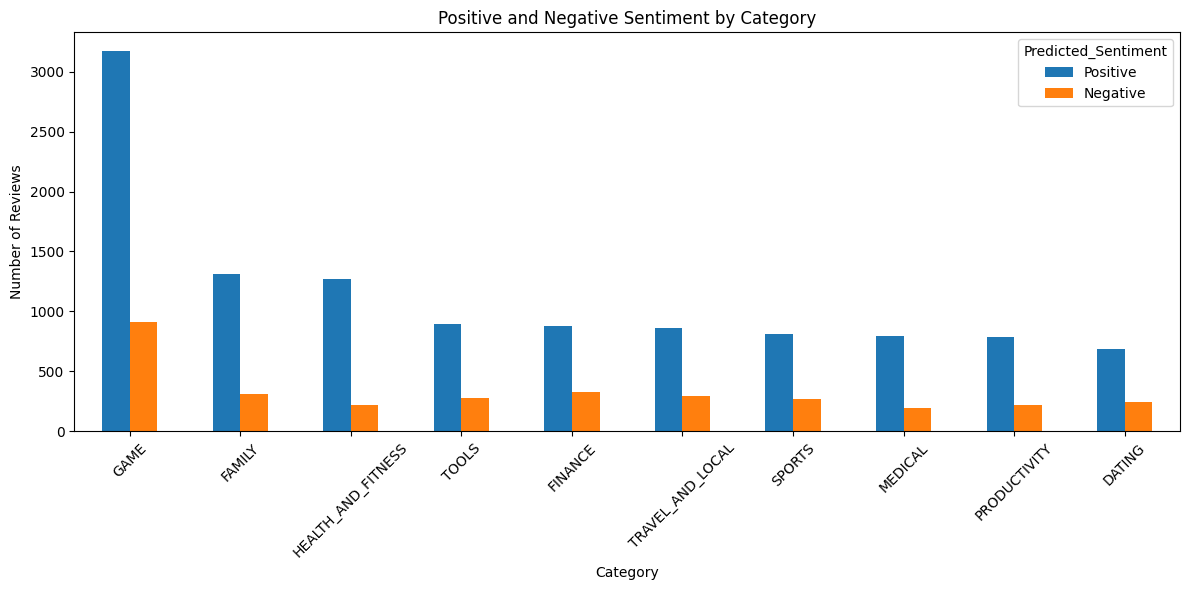

In [27]:
sentiment_by_category[['Positive', 'Negative']].sort_values(
    'Positive',
    ascending=False
).head(10).plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title('Positive and Negative Sentiment by Category')
plt.xlabel('Category')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Observation

Sentiment varies across app categories. Some categories receive more positive reviews, while others have a higher number of negative reviews. This helps developers understand user satisfaction and identify categories where users may have more concerns.

In [28]:
pip install plotly

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [29]:
import plotly.express as px
category_data = apps_df['Category'].value_counts().reset_index()

category_data.columns = ['Category', 'Number_of_Apps']

fig = px.bar(
    category_data,
    x='Category',
    y='Number_of_Apps',
    title='Interactive App Distribution Across Categories',
    labels={
        'Category': 'App Category',
        'Number_of_Apps': 'Number of Apps'
    }
)

fig.update_layout(
    xaxis_tickangle=-45
)

fig.show()

### Observation

The interactive visualization provides an easy way to explore the distribution of apps across different categories. Users can hover over individual categories to view the corresponding number of apps.

## 10. Conclusion

The Google Play Store analysis provided useful insights into app categories, ratings, app size, installs, pricing, and user sentiment.

### Key Insights

1. **Category Competition:** FAMILY is the most saturated category with 1,943 apps, followed by GAME and TOOLS. This indicates strong competition in these categories.

2. **App Size and Popularity:** The correlation between app size and number of installs is approximately 0.169, indicating a weak positive relationship. Therefore, app size alone is not a strong predictor of app popularity.

3. **Pricing and User Sentiment:** The analysis of paid applications and user reviews provides insights into pricing patterns and user satisfaction. Developers can use these findings to identify suitable pricing strategies and understand user expectations before launching a new application.

### Recommendations for Developers

- Consider less saturated categories to reduce competition.
- Focus on app quality and user experience rather than relying on app size to attract installs.
- Use pricing and user sentiment insights to develop an appropriate monetization strategy and improve user satisfaction.